# Estimación de peso de pollos

## Colegio de Posgraduados

### COA661 Inteligencia Artificial

Profesor: Dr. Juan Manuel González Camacho

Entrega: José Alfredo Martínez

En este notebook se entrenan un modelo Random Forest con las 3 características más importantes

In [1]:
#Librerías
import numpy as np
import pandas as pd
import time

import optuna

from IPython.display import clear_output

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score
import sklearn.model_selection
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.base import clone

import joblib

import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Código

In [2]:
# Cargar datos
datos = pd.read_excel('datosPesoPollo.xlsx')
fil, col = datos.shape

X = datos.iloc[:, 1 : col - 1].to_numpy()
Y = datos.iloc[:, col - 1].to_numpy()

# Datos de entrenamiento y test, aplicar proporción 80 : 20
clases, Y_class = np.unique(Y, return_inverse = True)
print('Clases: ', clases)
print('y_class: ', Y_class)

X_train, X_test, Y_train_class, Y_test_class = train_test_split(X, Y_class, test_size = 0.2, random_state = 42, stratify = Y_class)
y_train = clases[Y_train_class]
y_test = clases[Y_test_class]

print('y_train: ', y_train)
print('y_train_class: ', Y_train_class)

print('Datos de train: ', X_train.shape[0])
print('Datos de test: ', X_test.shape[0])

Clases:  [1.755 1.775 1.89  1.895 1.92  2.105 2.14  2.165 2.2   2.205 2.305 2.33
 2.335 2.35  2.385 2.445 2.46  2.5   2.52  2.525 2.6   2.605 2.635 2.655
 2.665 2.675 2.68  2.695 2.705 2.735 2.76  2.765 2.775 2.86  2.94  2.995]
y_class:  [ 0  0  0 ... 35 35 35]
y_train:  [2.605 2.665 2.52  ... 1.775 2.665 2.775]
y_train_class:  [21 24 18 ...  1 24 32]
Datos de train:  2439
Datos de test:  610


In [3]:
# Datos
x_train = X_train[:, [0, 2, 5, 6]]
x_test = X_test[:, [0, 2, 5, 6,]]

print(x_train.shape)
print(x_test.shape)

(2439, 4)
(610, 4)


## Random Forest Regressor
Usando 3 características más importantes

Encontrar hiperparámetros usando Optuna

Ejecutar si no existe el archivo del modelo

In [4]:
# Primera optimización con Optuna
def objective(trial):
    clear_output(wait = True)
    
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 2, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 15)
    
    r2_cv = []
    
    kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)
    
    for train_index, test_index in kfold:
        modelo = RandomForestRegressor(n_estimators = n_estimators, max_depth = max_depth, min_samples_split = min_samples_split, min_samples_leaf = min_samples_leaf, random_state = 42, n_jobs = -1)
        xx_train, xx_test = x_train[train_index], x_train[test_index]
        yy_train, yy_test = y_train[train_index], y_train[test_index]
        modelo.fit(xx_train, yy_train)
        r2_cv.append(modelo.score(xx_test, yy_test))
    
    return np.mean(r2_cv)

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 100)

# Imprimir los mejores hiperparámetros y R2
print('Cross Validation')
print('Mejores hiperparámetros: ', study.best_params)
print('R2: ', round(study.best_value, 2))

[I 2026-05-27 20:47:06,982] Trial 99 finished with value: 0.8571519161237587 and parameters: {'n_estimators': 436, 'max_depth': 27, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 53 with value: 0.8690321717118703.


Cross Validation
Mejores hiperparámetros:  {'n_estimators': 430, 'max_depth': 26, 'min_samples_split': 3, 'min_samples_leaf': 2}
R2:  0.87


In [5]:
a1 = max(1, study.best_params['n_estimators'] - 25)
a2 = study.best_params['n_estimators'] + 25

b1 = max(2, study.best_params['max_depth'] - 3)
b2 = study.best_params['max_depth'] + 3

c1 = max(2, study.best_params['min_samples_split'] - 3)
c2 = study.best_params['min_samples_split'] + 3

d1 = max(2, study.best_params['min_samples_leaf'] - 3)
d2 = study.best_params['min_samples_leaf'] + 3

print('n_estimators', a1, a2)
print('max_depth', b1, b2)
print('min_samples_split', c1, c2)
print('min_samples_leaf', d1, d2)

n_estimators 405 455
max_depth 23 29
min_samples_split 2 6
min_samples_leaf 2 5


In [6]:
# Segunda optimización con Optuna
def objective(trial):
    clear_output(wait = True)
    
    n_estimators = trial.suggest_int('n_estimators', a1, a2)
    max_depth = trial.suggest_int('max_depth', b1, b2)
    min_samples_split = trial.suggest_int('min_samples_split', c1, c2)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', d1, d2)

    r2_cv = []
    
    kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)
    
    for train_index, test_index in kfold:
        modelo = RandomForestRegressor(n_estimators = n_estimators, max_depth = max_depth, min_samples_split = min_samples_split, min_samples_leaf = min_samples_leaf, random_state = 42, n_jobs = -1)
        xx_train, xx_test = x_train[train_index], x_train[test_index]
        yy_train, yy_test = y_train[train_index], y_train[test_index]
        modelo.fit(xx_train, yy_train)
        r2_cv.append(modelo.score(xx_test, yy_test))
    
    return np.mean(r2_cv)

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 30)

# Imprimir los mejores hiperparámetros y R2
print('Cross Validation')
print('Mejores hiperparámetros: ', study.best_params)
print('R2: ', round(study.best_value, 2))

[I 2026-05-27 20:49:50,785] Trial 29 finished with value: 0.8643238504194887 and parameters: {'n_estimators': 428, 'max_depth': 23, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 25 with value: 0.8690320931086826.


Cross Validation
Mejores hiperparámetros:  {'n_estimators': 429, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 2}
R2:  0.87


In [7]:
# Guardar Modelo
rf = RandomForestRegressor(**study.best_params)
joblib.dump(rf, './modelo_RF_RF4.pkl')

['./modelo_RF_RF4.pkl']

Cargar el modelo y realizar métricas

In [8]:
# Cross Validation
rf_base = joblib.load('./modelo_RF_RF4.pkl')
R2s = []

kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)

for train_index, test_index in kfold:
    rf = clone(rf_base)
    xx_train, xx_test = x_train[train_index], x_train[test_index]
    yy_train, yy_test = y_train[train_index], y_train[test_index]
    rf.fit(xx_train, yy_train)
    R2s.append(rf.score(xx_test, yy_test))

print('R2 por fold: ', np.array(R2s))
print(f'R2 CV = {round(np.mean(R2s), 2)} +- {round(np.array(R2s).std(), 3)}')

R2 por fold:  [0.86219659 0.87805234 0.82840936 0.84907168 0.89434039 0.85062229
 0.88851937 0.89103137 0.89475193 0.84157862]
R2 CV = 0.87 +- 0.023


In [9]:
# Entrenamiento de modelo
rf = clone(rf_base)
rf.fit(x_train, y_train)

,n_estimators,429
,criterion,'squared_error'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
# Predecir datos
inicio = time.time()
y_pred_train = rf.predict(x_train)
y_pred_test = rf.predict(x_test)
fin = time.time()

print('Tiempo de predicción: ', round(fin - inicio, 3), 's')

Tiempo de predicción:  0.148 s


In [11]:
# Métricas de evaluación
E = mean_squared_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

print('Datos de entrenamiento')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

E = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print('Datos de test')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

Datos de entrenamiento
Error cuadrático medio:  0.003
R2:  0.97
Datos de test
Error cuadrático medio:  0.013
R2:  0.88


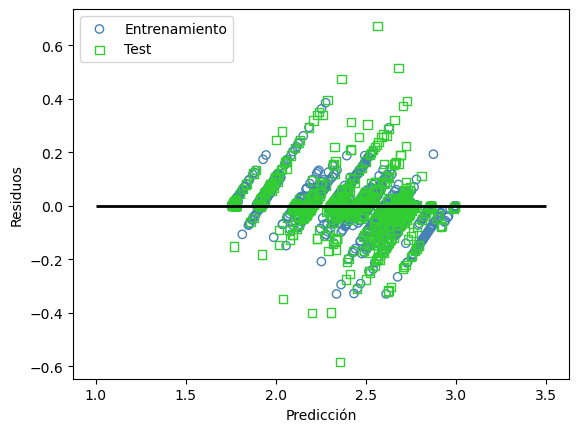

In [12]:
# Graficar datos
plt.scatter(y_pred_train, y_pred_train - y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(y_pred_test, y_pred_test - y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.hlines(y = 0, xmin = 1, xmax = 3.5, color = 'black', lw = 2)

plt.xlabel('Predicción')
plt.ylabel('Residuos')
plt.legend(loc = 'upper left')
plt.show()

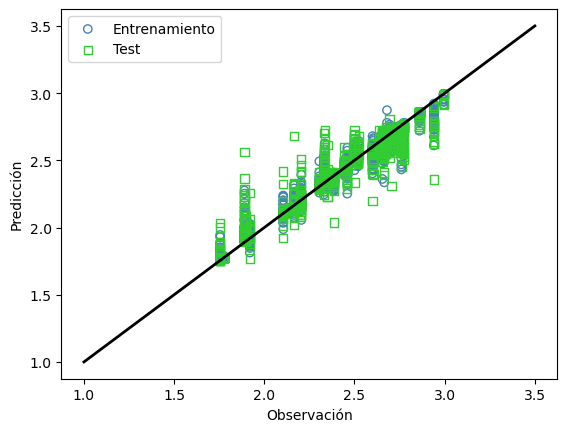

In [13]:
# Graficar datos
plt.scatter(y_train, y_pred_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(y_test, y_pred_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.plot([1, 3.5], [1, 3.5], color = 'black', lw=2)


plt.xlabel('Observación')
plt.ylabel('Predicción')
plt.legend(loc = 'upper left')
plt.show()

## Adaboost Regressor
Usando 5 características que más aportan al peso

### Hiperparámetros

Ejecutar si no existe el archivo del modelo

In [14]:
# Primera optimización con Optuna
def objective(trial):
    clear_output(wait = True)
    
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 1, 7)
    learning_rate = trial.suggest_float('learning_rate', 0.0001, 1, log = True)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    r2_cv = []
    
    kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)
    
    for train_index, test_index in kfold:
        modelo = AdaBoostRegressor(estimator = DecisionTreeRegressor(max_depth = max_depth, min_samples_leaf = min_samples_leaf), n_estimators = n_estimators, learning_rate = learning_rate, random_state = 42)
        xx_train, xx_test = x_train[train_index], x_train[test_index]
        yy_train, yy_test = y_train[train_index], y_train[test_index]
        modelo.fit(xx_train, yy_train)
        r2 = modelo.score(xx_test, yy_test)
        r2_cv.append(r2)
    
    return np.mean(r2_cv)

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 100)

# Imprimir los mejores hiperparámetros y R2
print('Cross Validation')
print('Mejores hiperparámetros: ', study.best_params)
print('R2: ', round(study.best_value, 2))

[I 2026-05-27 21:04:59,464] Trial 99 finished with value: 0.7913267887386869 and parameters: {'n_estimators': 262, 'max_depth': 6, 'learning_rate': 0.8601279546424829, 'min_samples_leaf': 1}. Best is trial 77 with value: 0.8396134947170278.


Cross Validation
Mejores hiperparámetros:  {'n_estimators': 253, 'max_depth': 7, 'learning_rate': 0.7925900531400564, 'min_samples_leaf': 1}
R2:  0.84


In [15]:
a1 = max(1, study.best_params['n_estimators'] - 25)
a2 = study.best_params['n_estimators'] + 25

b1 = max(1, study.best_params['max_depth'] - 2)
b2 = study.best_params['max_depth'] + 2

c1 = max(0.0001, study.best_params['learning_rate'] - 0.1)
c2 = min(1, study.best_params['learning_rate'] + 0.1)

d1 = max(1, study.best_params['min_samples_leaf'] - 2)
d2 = study.best_params['min_samples_leaf'] + 2

print('n_estimators', a1, a2)
print('max_depth', b1, b2)
print('learning_rate', c1, c2)
print('min_samples_leaf', d1, d2)

n_estimators 228 278
max_depth 5 9
learning_rate 0.6925900531400564 0.8925900531400563
min_samples_leaf 1 3


In [16]:
# Segunda optimización con Optuna
def objective(trial):
    clear_output(wait = True)
    
    n_estimators = trial.suggest_int('n_estimators', a1, a2)
    max_depth = trial.suggest_int('max_depth', b1, b2)
    learning_rate = trial.suggest_float('learning_rate', c1, c2, log = True)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', d1, d2)

    r2_cv = []
    
    kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)
    
    for train_index, test_index in kfold:
        modelo = AdaBoostRegressor(estimator = DecisionTreeRegressor(max_depth = max_depth, min_samples_leaf = min_samples_leaf), n_estimators = n_estimators, learning_rate = learning_rate, random_state = 42)
        xx_train, xx_test = x_train[train_index], x_train[test_index]
        yy_train, yy_test = y_train[train_index], y_train[test_index]
        modelo.fit(xx_train, yy_train)
        r2 = modelo.score(xx_test, yy_test)
        r2_cv.append(r2)
    
    return np.mean(r2_cv)

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 30)

# Imprimir los mejores hiperparámetros y R2
print('Cross Validation')
print('Mejores hiperparámetros: ', study.best_params)
print('R2: ', round(study.best_value, 2))

[I 2026-05-27 21:09:48,851] Trial 29 finished with value: 0.7894372570339699 and parameters: {'n_estimators': 255, 'max_depth': 6, 'learning_rate': 0.7703775213527523, 'min_samples_leaf': 1}. Best is trial 23 with value: 0.8932183104891195.


Cross Validation
Mejores hiperparámetros:  {'n_estimators': 264, 'max_depth': 9, 'learning_rate': 0.8309658534720196, 'min_samples_leaf': 1}
R2:  0.89


In [17]:
# Guardar Modelo
ada = AdaBoostRegressor(estimator = DecisionTreeRegressor(max_depth = study.best_params['max_depth'], min_samples_leaf = study.best_params['min_samples_leaf']),
                        n_estimators = study.best_params['n_estimators'],
                       learning_rate = study.best_params['learning_rate'],
                       random_state = 42)

joblib.dump(ada, './modelo_ada_RF4.pkl')

['./modelo_ada_RF4.pkl']

### Entrenamiento

In [18]:
# Cross Validation
ada_base = joblib.load('./modelo_ada_RF4.pkl')
R2s = []

kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42).split(x_train, Y_train_class)

for train_index, test_index in kfold:
    ada = clone(ada_base)
    xx_train, xx_test = x_train[train_index], x_train[test_index]
    yy_train, yy_test = y_train[train_index], y_train[test_index]
    ada.fit(xx_train, yy_train)
    R2s.append(ada.score(xx_test, yy_test))

print('R2 por fold: ', np.array(R2s))
print(f'R2 CV = {round(np.mean(R2s), 2)} +- {round(np.array(R2s).std(), 3)}')

R2 por fold:  [0.90155138 0.8941541  0.86469124 0.88908091 0.90451859 0.87980564
 0.9088829  0.90569887 0.89450818 0.88929128]
R2 CV = 0.89 +- 0.013


In [19]:
# Entrenamiento de modelo
ada = clone(ada_base)
ada.fit(x_train, y_train)

,estimator,DecisionTreeR...r(max_depth=9)
,n_estimators,264
,learning_rate,0.8309658534720196
,loss,'linear'
,random_state,42
,criterion,'squared_error'
,splitter,'best'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [20]:
# Predecir datos
inicio = time.time()
y_pred_train = ada.predict(x_train)
y_pred_test = ada.predict(x_test)
fin = time.time()

print('Tiempo de predicción: ', round(fin - inicio, 3), 's')

Tiempo de predicción:  0.108 s


In [21]:
# Métricas de evaluación
E = mean_squared_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

print('Datos de entrenamiento')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

E = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print('Datos de test')
print('Error cuadrático medio: ', round(E, 3))
print('R2: ', round(r2, 2))

Datos de entrenamiento
Error cuadrático medio:  0.003
R2:  0.97
Datos de test
Error cuadrático medio:  0.012
R2:  0.89


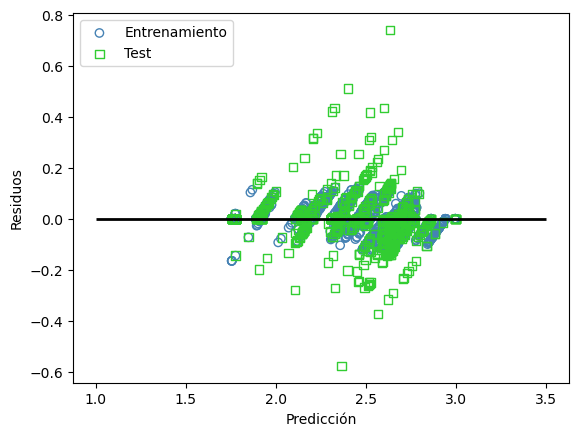

In [22]:
# Graficar datos
plt.scatter(y_pred_train, y_pred_train - y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(y_pred_test, y_pred_test - y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.hlines(y = 0, xmin = 1, xmax = 3.5, color = 'black', lw = 2)

plt.xlabel('Predicción')
plt.ylabel('Residuos')
plt.legend(loc = 'upper left')
plt.show()

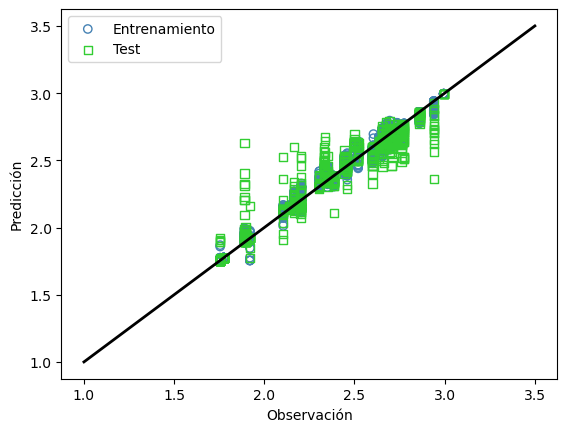

In [23]:
# Graficar datos
plt.scatter(y_train, y_pred_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(y_test, y_pred_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')
plt.plot([1, 3.5], [1, 3.5], color = 'black', lw=2)


plt.xlabel('Observación')
plt.ylabel('Predicción')
plt.legend(loc = 'upper left')
plt.show()